### Instituto Superior Tecnologico Quito

![jupyter](img/itq.png)

**Nombre:** Alan Velasco

**Fecha:** 7/04/20236

# Caso Práctico: Neurona de McCulloch y Pitts
### Aplicando la MPNeurona en un caso práctico real

## 2.1. Conjunto de datos

Esta es una copia de los conjuntos de datos de UCI ML Breast Cancer Wisconsin: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

### Descripción de la muestra

Las características de entrada se calculan a partir de una imagen digitalizada de un aspirado de aguja fina (FNA) de una masa mamaria. Describen las características de los núcleos celulares presentes en la imagen.

El plano de separación descrito anteriormente se obtuvo utilizando el método de árbol de múltiples superficies (MSM-T): "Construcción de un árbol de decisión mediante programación lineal".

El programa final utilizado para obtener el plano de separación en el espacio tridimensional es el que describe en [K.P. Bennett y O.L. Mangasarian].

### Lectura de datos

In [2]:
from sklearn.datasets import load_breast_cancer
cancer_mama = load_breast_cancer()

# Datos de entrada
X = cancer_mama.data

# Datos de salida
y = cancer_mama.target

In [3]:
dir(cancer_mama)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [4]:
print(X)

[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]


### Visualización del conjunto de datos

In [5]:
import pandas as pd

#Creación del DataFrame y  X es la matriz de datos (probablemente obtenida de un dataset como load_breast_cancer de sklearn).
df = pd.DataFrame(X, columns=cancer_mama.feature_names)

df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [6]:
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 0 1 1 0 

### División del conjunto de datos

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df, y, stratify=y)
print("Tamaño de entrenamiento:", len(X_train))
print("Tamaño de prueba:", len(X_test))

Tamaño de entrenamiento: 426
Tamaño de prueba: 143


## Implementación de un aMP Neurona más avanzada

In [15]:
# Importamos las bibliotecas necesarias
import numpy as np
from sklearn.metrics import accuracy_score

# Definimos la clase MPNeurona
class MPNeurona:
    def __init__(self):
        # Inicializamos el umbral en None
        self.threshold = None

    def model(self, x):
        # Calculamos la suma de las entradas
        x = sum(x)
        # La neurona se activa si la suma >= umbral
        return (x >= self.threshold)

    def predict(self, X):
        # Generamos predicciones para cada fila de X
        Y = []
        for x in X:
            result = self.model(x)
            Y.append(result)
        # Convertimos la lista en un array de numpy
        return np.array(Y)

    def fit(self, X, Y):
        # Diccionario para guardar la precisión por cada umbral
        accuracy = {}
        # Probamos umbrales desde 0 hasta el número de características
        for th in range(X.shape[1] + 1):
            self.threshold = th
            y_pred = self.predict(X)
            # Calculamos la precisión con este umbral
            accuracy[th] = accuracy_score(y_pred, Y)
        # Elegimos el umbral con mejor precisión
        self.threshold = max(accuracy, key=accuracy.get)

Los datos de entrada siguen teniendo problemas debido a que el conjunto de datos las características de entrada contienen valores continuos, sin embargo, la neurona MP solo procesa características de entrada con valores binarios.

[0, 0, 1, 1, 1, 0, 0]
Categories (2, int64): [0 < 1]


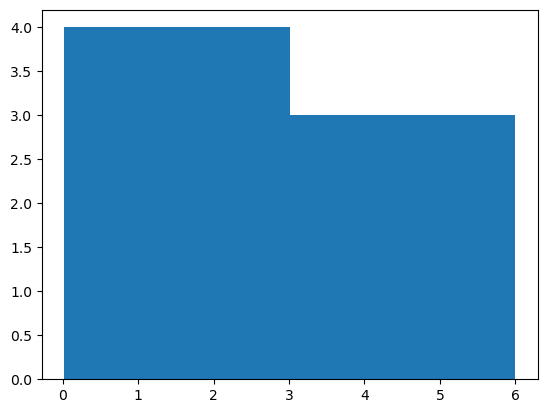

In [9]:
# Antes transformamos los valores en un valor binario
import matplotlib.pyplot as plt
print(pd.cut([0.04,0.3,4,5,6,0.02,0.6], bins=2, labels=[0,1]))
plt.hist([0.04,0.3,4,5,6,0.02,0.6], bins=2)
plt.show()

In [10]:
# Visualizamos las características de entrada para el valor binario
import pandas as pd

# Convertimos a DataFrame para poder usar .apply()
X_train = pd.DataFrame(X_train)
X_test  = pd.DataFrame(X_test)

# Ahora tu código funciona sin cambios
X_train_bin = X_train.apply(pd.cut, bins=2, labels=[1,0])
X_test_bin  = X_test.apply(pd.cut, bins=2, labels=[1,0])

X_train_bin

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
384,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
58,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
388,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
180,0,1,0,0,0,0,0,0,1,1,...,0,0,0,0,1,1,1,0,1,1
396,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,0,1,1,1,1,1
505,1,1,1,1,0,0,1,1,0,0,...,1,1,1,1,0,1,1,1,1,0
558,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
391,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1,1


In [11]:
# Entrenamos el modelo MP
np_neurona = MPNeurona()

np_neurona.fit(X_train_bin.to_numpy(), y_train)

# Obtenemos el threshold
np_neurona.threshold

27

In [12]:
# Realizamos la predicción por una clase de prueba
y_pred = np_neurona.predict(X_test_bin.to_numpy())

In [13]:
y_pred

array([ True, False, False, False,  True, False, False,  True,  True,
        True, False,  True,  True,  True, False, False, False, False,
        True, False, False, False,  True, False, False,  True,  True,
        True, False,  True,  True,  True, False, False,  True, False,
        True, False,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True, False, False,  True,  True,
        True, False,  True, False,  True,  True,  True, False, False,
        True,  True,  True,  True,  True, False,  True,  True,  True,
       False,  True, False,  True,  True,  True, False,  True,  True,
        True, False,  True,  True,  True, False, False,  True, False,
        True, False, False,  True,  True,  True,  True, False, False,
        True,  True,  True, False, False,  True,  True, False, False,
       False, False, False, False, False,  True,  True, False, False,
       False,  True,

In [14]:
accuracy_score(y_test, y_pred)

0.9370629370629371

In [19]:
# Importamos la función de la matriz de confusion 
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Matriz de confusión:")
print(cm)

Matriz de confusión:
[[51  2]
 [ 7 83]]


### **Trabajo en clase**

In [44]:
# Importamos las librerías necesarias
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Cargamos el dataset de cáncer de mama
cancer_mama = load_breast_cancer()

# Datos de entrada (X) y salida (y)
X = cancer_mama.data
y = cancer_mama.target

# Creamos un DataFrame con nombres de columnas
df = pd.DataFrame(X, columns=cancer_mama.feature_names)

print("Tamaño total del dataset:", df.shape)

Tamaño total del dataset: (569, 30)


### División en entrenamiento y prueba

In [45]:
# Dividimos el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(df, y, stratify=y, random_state=42)

print("Tamaño de entrenamiento:", len(X_train))
print("Tamaño de prueba:", len(X_test))

Tamaño de entrenamiento: 426
Tamaño de prueba: 143


In [46]:
# Definimos la clase de la neurona MP
class MPNeurona:
    def __init__(self):
        self.threshold = None

    def model(self, x):
        # La neurona se activa si la suma de entradas >= umbral
        return (sum(x) >= self.threshold)

    def predict(self, X):
        # Generamos predicciones para cada fila de X
        Y = []
        for x in X:
            Y.append(self.model(x))
        return np.array(Y)

    def fit(self, X, Y):
        # Buscamos el umbral que da mejor precisión
        accuracy = {}
        for th in range(X.shape[1] + 1):
            self.threshold = th
            y_pred = self.predict(X)
            accuracy[th] = accuracy_score(y_pred, Y)
        self.threshold = max(accuracy, key=accuracy.get)

### Transformación binaria de las características

In [47]:
# Convertimos a DataFrame para usar .apply()
X_train = pd.DataFrame(X_train)
X_test  = pd.DataFrame(X_test)

# Transformamos a valores binarios (0 o 1)
X_train_bin = X_train.apply(pd.cut, bins=2, labels=[1,0])
X_test_bin  = X_test.apply(pd.cut, bins=2, labels=[1,0])

# Seleccionamos las 10 características más importantes
top10_features = [
    'worst radius','worst perimeter','worst area',
    'mean concave points','worst concave points',
    'mean radius','mean perimeter','mean area',
    'worst texture','mean concavity'
]

# Filtramos solo esas columnas
X_train_bin_top10 = X_train_bin[top10_features]
X_test_bin_top10  = X_test_bin[top10_features]

X_train_bin_top10.head()

,worst radius,worst perimeter,worst area,mean concave points,worst concave points,mean radius,mean perimeter,mean area,worst texture,mean concavity
517,0,0,1,1,0,0,0,1,1,1
287,1,1,1,1,1,1,1,1,1,1
25,0,0,1,0,0,1,1,1,1,0
253,1,1,1,1,0,1,1,1,1,1
369,0,0,0,0,0,0,0,0,1,0


In [48]:
# Entrenamos el modelo con las 10 características más importantes
np_neurona = MPNeurona()
np_neurona.fit(X_train_bin_top10.to_numpy(), y_train)

print("Umbral elegido:", np_neurona.threshold)

Umbral elegido: 10


In [50]:
# Realizamos predicciones usando solo las 10 características
y_pred = np_neurona.predict(X_test_bin_top10.to_numpy())


print("Predicciones:", y_pred[:20])

Predicciones: [ True False False  True False False False False False  True False  True
 False False False  True False False  True  True]


In [53]:
3# El usuario ingresa los valores de las 10 características más importantes
valores_usuario = [
    float(input("worst radius: ")),
    float(input("worst perimeter: ")),
    float(input("worst area: ")),
    float(input("mean concave points: ")),
    float(input("worst concave points: ")),
    float(input("mean radius: ")),
    float(input("mean perimeter: ")),
    float(input("mean area: ")),
    float(input("worst texture: ")),
    float(input("mean concavity: "))
]

# Creamos un DataFrame con los valores ingresados
valores_df = pd.DataFrame([valores_usuario], columns=top10_features)

# Transformamos a binario
valores_bin = valores_df.apply(pd.cut, bins=2, labels=[1,0])

# Realizamos la predicción
prediccion = np_neurona.predict(valores_bin.to_numpy())

# Mostramos resultado
if prediccion[0] == 1:
    print(" Diagnóstico: Posible cáncer maligno")
else:
    print(" Diagnóstico: Posible tumor benigno")

worst radius:  5229.00
worst perimeter:  541.26
worst area:  0.2315
mean concave points:  1548
worst concave points:  1254
mean radius:  154
mean perimeter:  0.3698
mean area:  2547
worst texture:  0.2369
mean concavity:  17456


 Diagnóstico: Posible cáncer maligno
